In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['AAPL', 'MSFT', 'AMZN']
start_date = '2023-01-01'
end_date = '2026-08-07'

data = yf.download(
    tickers,
    start=start_date,
    end=end_date
)['Close']

data.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,AMZN,MSFT
Date,,,
2023-01-03,122.982727,85.820000,232.948288
2023-01-04,124.251183,85.139999,222.758347
2023-01-05,122.933556,83.120003,216.156265
2023-01-06,127.456764,86.080002,218.703796
2023-01-09,127.977951,87.360001,220.833160


In [21]:
# Calculating the daily returns
returns = data.pct_change().dropna()

In [22]:
# Assume equal weights for each stock
weights = np.array([1/len(tickers)] * len(tickers))

# Calculate the portfolio daily returns
portfolio_returns = returns.dot(weights)

In [23]:
# Calculate portfolio value over time, starting with $10,000
initial_investment = 20000
portfolio_value = initial_investment * (1 + portfolio_returns).cumprod()

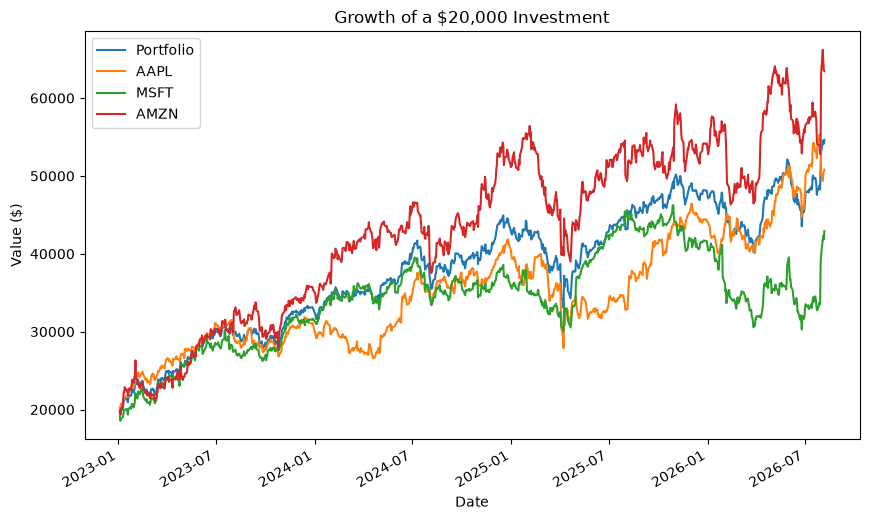

In [24]:
# Plot the portfolio value and individual stock values
plt.figure(figsize=(10, 6))
portfolio_value.plot(label='Portfolio')
for ticker in tickers:
    stock_value = initial_investment * (1 + returns[ticker]).cumprod()
    stock_value.plot(label=ticker)
plt.title('Growth of a $20,000 Investment')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.show()